In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [10]:
titanic.head()
titanic.isnull().sum()
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [11]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [12]:
# encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [13]:
x = titanic[features]
y = titanic["survived"]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state=42
)

In [15]:
x_train.head()

,pclass,sex,fare,embarked,age
445,1,1,81.8583,2,4.0
650,3,1,7.8958,2,28.0
172,3,0,11.1333,2,1.0
450,2,1,27.7500,2,36.0
314,2,1,26.2500,2,43.0


In [16]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
from sklearn.metrics import accuracy_score
y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)


# Classic case of over fitting
print("accuracy for testing data: ", accuracy_score(y_test, y_pred_test))
print("accuracy for training data: ", accuracy_score(y_train, y_pred_train))

accuracy for testing data:  0.7649253731343284
accuracy for training data:  0.9791332263242376


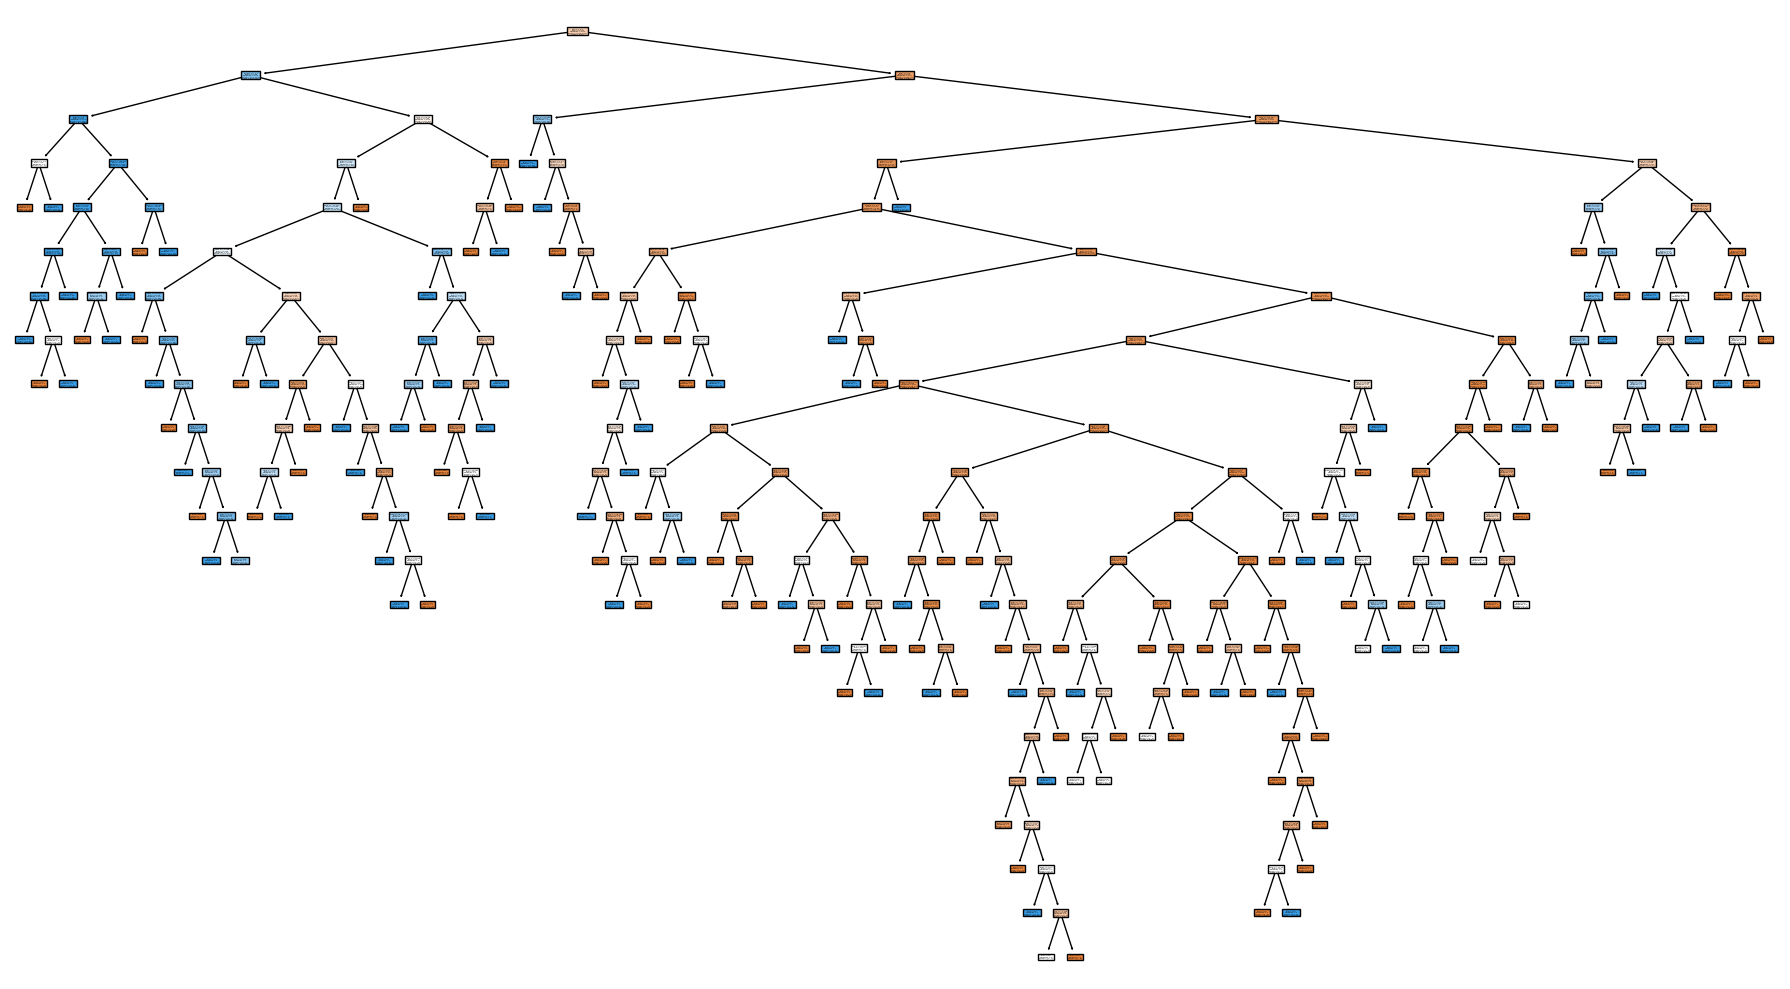

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True
    
)

plt.tight_layout()
plt.show()

In [31]:
#Random forest classifier


from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=201,oob_score=True)

rf.fit(x_train,y_train)


y_pred_test=rf.predict(x_test)
y_pred_train = rf.predict(x_train)

print("oob_score :",rf.oob_score_*100,"%")
print("testing accuracy :",accuracy_score(y_test,y_pred_test)*100,"%")
print("accuracy for training data: ", accuracy_score(y_train, y_pred_train))

oob_score : 80.41733547351525 %
testing accuracy : 77.23880597014924 %
accuracy for training data:  0.9791332263242376


# bagging classifier 

In [32]:
from sklearn.ensemble import BaggingClassifier


base_model=DecisionTreeClassifier()

model=BaggingClassifier(
    base_model,
    n_estimators=201,
    oob_score=True

)

model.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,201
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [33]:
y_pred_test=model.predict(x_test)
y_pred_train = model.predict(x_train)

print("oob_score :",model.oob_score_*100,"%")
print("testing accuracy :",accuracy_score(y_test,y_pred_test)*100,"%")
print("accuracy for training data: ", accuracy_score(y_train, y_pred_train))

oob_score : 80.41733547351525 %
testing accuracy : 77.98507462686567 %
accuracy for training data:  0.9791332263242376


In [34]:
# bagging for logistic regression


from sklearn.linear_model import LogisticRegression

base_model=LogisticRegression()
model=BaggingClassifier(
    base_model,
    n_estimators=201,
    oob_score=True
)
model.fit(x_train,y_train)

,estimator,LogisticRegression()
,n_estimators,201
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [35]:
y_pred_test=model.predict(x_test)
y_pred_train = model.predict(x_train)

print("oob_score :",model.oob_score_*100,"%")
print("testing accuracy :",accuracy_score(y_test,y_pred_test)*100,"%")
print("accuracy for training data: ", accuracy_score(y_train, y_pred_train))

oob_score : 78.97271268057786 %
testing accuracy : 79.47761194029852 %
accuracy for training data:  0.7913322632423756
